# 02 - Feature Engineering and Clustering

In the previous notebook, I inspected the raw Steam interaction data and created a user-level feature table.  
In this notebook, I use those user-level behavioral features for clustering and PCA visualization.

## 2. Load the processed user-level data

The raw interaction data was already converted into user-level features in the previous step.  
This processed table is more suitable for clustering because each row now represents one user.

In [91]:
user_features_path = PROCESSED_DATA_DIR / "user_features.csv"

user_features = pd.read_csv(user_features_path)
user_features.head()

,user_id,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio
0,5250,225.5,8.351852,144.0,21,21,27,10.738095,0.777778
1,76767,1227.0,21.910714,365.0,36,36,56,34.083333,0.642857
2,86540,255.0,2.628866,113.0,82,82,97,3.109756,0.845361
3,103360,0.0,0.000000,0.0,10,10,10,0.000000,1.000000
4,144736,0.1,0.011111,0.1,8,8,9,0.012500,0.888889


In [92]:
user_features.shape

(12393, 9)

In [93]:
user_features.describe()

,user_id,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio
count,1.239300e+04,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000
mean,1.611377e+08,278.009021,30.123010,176.163520,10.393287,10.393287,16.081094,55.471616,0.609983
std,8.001490e+07,760.270618,125.155644,504.764658,35.635890,35.635890,51.653103,241.296617,0.157643
min,5.250000e+03,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.500000
25%,9.706903e+07,1.300000,0.450000,1.200000,1.000000,1.000000,2.000000,0.833333,0.500000
50%,1.649396e+08,13.500000,3.200000,11.600000,2.000000,2.000000,3.000000,5.676923,0.500000
75%,2.209560e+08,155.600000,15.927586,107.000000,6.000000,6.000000,9.000000,27.500000,0.666667
max,3.099031e+08,11754.000000,5877.000000,11754.000000,1068.000000,1068.000000,1566.000000,11754.000000,1.000000


## 3. Select behavioral features for clustering

The `user_id` column is only an identifier, so I do not use it as an input feature.  
The remaining columns describe gameplay intensity, game library diversity, and purchasing behavior.

In [94]:
feature_columns = [
    "total_hours",
    "avg_hours",
    "max_hours",
    "unique_games",
    "purchase_count",
    "total_interactions",
    "hours_per_game",
    "purchase_ratio"
]

X = user_features[feature_columns]

X.head()

,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio
0,225.5,8.351852,144.0,21,21,27,10.738095,0.777778
1,1227.0,21.910714,365.0,36,36,56,34.083333,0.642857
2,255.0,2.628866,113.0,82,82,97,3.109756,0.845361
3,0.0,0.000000,0.0,10,10,10,0.000000,1.000000
4,0.1,0.011111,0.1,8,8,9,0.012500,0.888889


## 4. Scale the features

K-Means is distance-based, so feature scaling is important.  
Without scaling, variables with larger numerical ranges could dominate the clustering result.

In [95]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.06906901, -0.17395969, -0.0637224 ,  0.29765333,  0.29765333,
         0.21139768, -0.18539558,  1.06443631],
       [ 1.24827824, -0.06561931,  0.37412306,  0.71859428,  0.71859428,
         0.77285805, -0.08864254,  0.20854228],
       [-0.03026547, -0.21968848, -0.12513964,  2.00947985,  2.00947985,
         1.56664684, -0.2170108 ,  1.49316189],
       [-0.36568589, -0.2406941 , -0.34901538, -0.01103669, -0.01103669,
        -0.11773425, -0.22989901,  2.47414414],
       [-0.36555435, -0.24060532, -0.34881726, -0.06716215, -0.06716215,
        -0.13709496, -0.22984721,  1.76929023]])

## 5. Elbow Method

I first calculate inertia values for different numbers of clusters.  
The goal is to see where adding more clusters starts to provide less improvement.

In [96]:
k_values = range(2, 11)
inertia_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=4, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

inertia_values

[72106.35026805408,
 55208.08415319276,
 45500.122019769326,
 36149.30870900376,
 28745.25364887927,
 24610.94736604404,
 21309.60931461627,
 18775.576857621843,
 17107.272610238593]

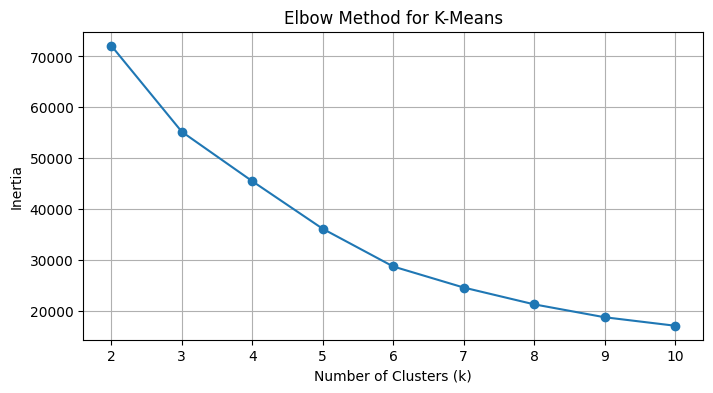

In [97]:
plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertia_values, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

## 7. Fit the final K-Means model

I considered both the scores and interpretability. I selected 4 clusters because it gives a manageable number of user profiles for explanation and dashboard presentation.
This gives enough detail to separate different user behaviors without making the segments too difficult to explain.

In [100]:
final_k = 4

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

clustered_users = user_features.copy()
clustered_users["cluster"] = cluster_labels

clustered_users.head()

,user_id,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio,cluster
0,5250,225.5,8.351852,144.0,21,21,27,10.738095,0.777778,1
1,76767,1227.0,21.910714,365.0,36,36,56,34.083333,0.642857,0
2,86540,255.0,2.628866,113.0,82,82,97,3.109756,0.845361,1
3,103360,0.0,0.000000,0.0,10,10,10,0.000000,1.000000,1
4,144736,0.1,0.011111,0.1,8,8,9,0.012500,0.888889,1


## 8. Cluster size distribution

Before interpreting the clusters, I check how many users are assigned to each cluster.

In [101]:
clustered_users["cluster"].value_counts().sort_index()

cluster
0    9355
1    2429
2     244
3     365
Name: count, dtype: int64

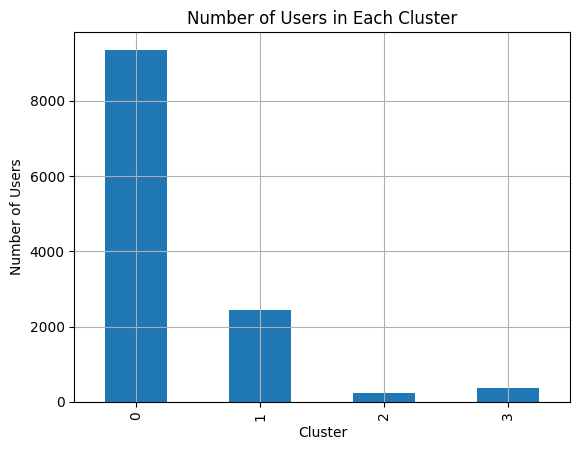

In [102]:
clustered_users["cluster"].value_counts().sort_index().plot(
    kind="bar",
    title="Number of Users in Each Cluster",
    xlabel="Cluster",
    ylabel="Number of Users",
    grid=True
)

plt.show()

## 9. Cluster profile summary

To understand the meaning of each cluster, I calculate the average behavioral features within each group.

In [103]:
cluster_summary = clustered_users.groupby("cluster")[feature_columns].mean()
cluster_summary

,total_hours,avg_hours,max_hours,unique_games,purchase_count,total_interactions,hours_per_game,purchase_ratio
cluster,,,,,,,,
0,173.928434,18.854983,109.433683,6.081988,6.081988,10.431427,35.335030,0.537404
1,89.924619,7.959843,75.662989,7.762042,7.762042,9.293536,9.892529,0.889819
2,2538.584426,9.955439,716.118852,202.204918,202.204918,299.168033,15.702658,0.666386
3,2686.092603,479.897278,2194.312329,10.178082,10.178082,16.810959,901.479829,0.570250


## 10. Simple cluster interpretation

At this stage, the clusters are still numeric labels.  
I use their average behavior to describe them in a more meaningful way.

In [104]:
cluster_summary[["total_hours", "unique_games", "purchase_count", "hours_per_game", "purchase_ratio"]].round(2)

,total_hours,unique_games,purchase_count,hours_per_game,purchase_ratio
cluster,,,,,
0,173.93,6.08,6.08,35.34,0.54
1,89.92,7.76,7.76,9.89,0.89
2,2538.58,202.20,202.20,15.70,0.67
3,2686.09,10.18,10.18,901.48,0.57


### Cluster interpretation based on summary statistics

The numeric cluster labels do not have meaning by themselves. I interpret the clusters by comparing the average values in the cluster summary table.

- **Cluster 0 - Moderate / Regular Players:**  
  This is the largest user group. The average **total playtime** is moderate, the number of **unique games** is relatively low, and the **purchase ratio** is more balanced compared with the other clusters. Therefore, I interpret this segment as regular users who play some of the games they own.

- **Cluster 1 - Low Engagement / Mostly Purchasers:**  
  This cluster has the lowest average **total playtime** and the lowest **hours per game**, while having the highest **purchase ratio**. This suggests that these users mostly appear as purchasers and spend relatively little time playing.

- **Cluster 2 - Broad Library / Collectors:**  
  This cluster has by far the highest average number of **unique games** and highest **purchase records**. The **total playtime** is also high, but the **hours per game** is not as extreme as Cluster 3. Therefore, I interpret this group as users with broad game libraries.

- **Cluster 3 - Focused Heavy Players:**  
  This cluster has very high **total playtime** and the highest **hours per game**, while the number of **unique games** is much lower than Cluster 2. This suggests that these users focus heavily on a smaller set of games.

These names are not original labels from the dataset. They are interpretation labels created after comparing the average behavior of each cluster.

## 11. PCA visualization

Since the clustering uses several features, I use PCA to reduce the data to two dimensions for visualization.

In [105]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = cluster_labels

pca_df.head()

,PC1,PC2,cluster
0,0.237745,-0.602949,1
1,1.608432,-0.507491,0
2,2.291693,-2.305510,1
3,-0.394632,-0.647804,1
4,-0.469946,-0.524588,1


The explained variance ratio shows how much of the original feature variation is represented by PC1 and PC2. This helps me understand how much information is retained in the two-dimensional PCA visualization.

In [106]:
pca.explained_variance_ratio_

array([0.4509365 , 0.33491221])

The explained variance ratio shows how much of the original scaled feature variation is captured by each principal component. In this output, **PC1 explains about 45.09%** of the variation and **PC2 explains about 33.49%**. Together, they explain about **78.58%** of the variation, so the two-dimensional PCA plot gives a useful visual summary of the user feature space.

In [107]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_columns,
    columns=["PC1", "PC2"]
)

pca_loadings

,PC1,PC2
total_hours,0.438967,0.160946
avg_hours,0.242228,0.503252
max_hours,0.362123,0.351187
unique_games,0.431143,-0.336791
purchase_count,0.431143,-0.336791
total_interactions,0.435524,-0.330142
hours_per_game,0.235267,0.499135
purchase_ratio,0.026459,-0.111878


The PCA loading table helps interpret what **PC1** and **PC2** are roughly related to. Larger absolute loading values mean that the original feature contributes more strongly to that principal component.

In this result, **PC1** is mainly influenced by **total_hours**, **total_interactions**, **unique_games**, **purchase_count**, and **max_hours**. Therefore, PC1 seems to represent a general user activity or engagement direction.

**PC2** is mainly influenced positively by **avg_hours**, **hours_per_game**, and **max_hours**, while **unique_games**, **purchase_count**, and **total_interactions** contribute negatively. This suggests that PC2 roughly separates users who spend more time per game from users with broader game libraries and more interactions.

The **purchase_ratio** feature has relatively low loading values in both PC1 and PC2, so it does not strongly define the first two PCA dimensions. However, it is still useful in clustering because it represents the balance between purchasing and playing behavior.

PC1 and PC2 should not be interpreted as single original variables. They are combined directions created from the scaled user-level features.

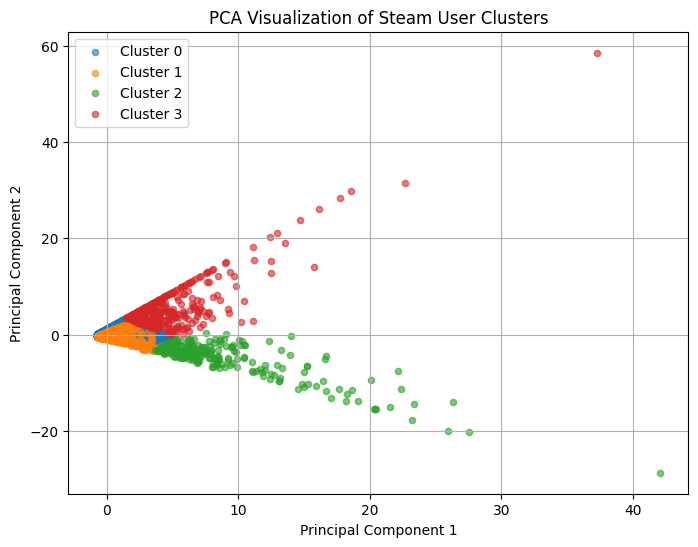

In [108]:
plt.figure(figsize=(8, 6))

for cluster_id in sorted(pca_df["cluster"].unique()):
    temp = pca_df[pca_df["cluster"] == cluster_id]
    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.6,
        s=20
    )

plt.title("PCA Visualization of Steam User Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

This PCA plot is used as a visual summary of the clusters. The K-Means model was fitted using the full scaled feature set, not only **PC1** and **PC2**. Therefore, this plot should be interpreted as a two-dimensional view of the cluster structure rather than the complete clustering space.

In the plotting code, the `for` loop goes through each cluster one by one. For each cluster, it filters the users belonging to that cluster and plots their **PC1** and **PC2** coordinates separately. This makes it possible to show each cluster as a different group in the same PCA scatter plot.

## 13. Save clustered users

The next notebook will use the cluster labels as a target-like variable for model comparison and interpretation.  
This does not mean the clusters are true external labels; they are labels discovered by K-Means.

In [109]:
clustered_users_path = PROCESSED_DATA_DIR / "clustered_users.csv"

clustered_users.to_csv(clustered_users_path, index=False)

clustered_users_path

PosixPath('/Users/ismailozcan/Desktop/ds570-final-project/data/processed/clustered_users.csv')

The clustered user table is saved so that the K-Means segment labels can be reused in the next steps. This file contains the user-level behavioral features together with the cluster assigned to each user.

These cluster labels are not original labels from the dataset. They are created by the K-Means model. In the next notebook, I use them as a target-like variable only for model comparison and interpretation, not as true external ground-truth labels.
